In [1]:
%pip install pandas numpy matplotlib openpyxl xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Main project folder
BASE_DIR = Path(
    r"D:\PHD\Research Paper writing\3rd Obj. paper"
)

# Output folders
RESULTS_DIR = BASE_DIR / "results"
AUDIT_DIR = RESULTS_DIR / "dataset_audit"
FIGURES_DIR = BASE_DIR / "figures" / "dataset_audit"

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", BASE_DIR)
print("Audit output folder:", AUDIT_DIR)
print("Figure folder:", FIGURES_DIR)

Project folder: D:\PHD\Research Paper writing\3rd Obj. paper
Audit output folder: D:\PHD\Research Paper writing\3rd Obj. paper\results\dataset_audit
Figure folder: D:\PHD\Research Paper writing\3rd Obj. paper\figures\dataset_audit


In [2]:
def locate_file(patterns):
    """
    Find the first file matching any supplied pattern.
    """
    for pattern in patterns:
        matches = list(BASE_DIR.glob(pattern))
        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"No file found for patterns: {patterns}\n"
        f"Available files: {[p.name for p in BASE_DIR.iterdir()]}"
    )


AUSTRALIAN_FILE = locate_file([
    "*Australian_Credit_Approval*.csv",
    "*Australian*Credit*Approval*.csv"
])

GERMAN_FILE = locate_file([
    "*GermanCredit*.csv",
    "*German*Credit*.csv"
])

TAIWAN_FILE = locate_file([
    "*default*credit*card*clients*.xls",
    "*default*credit*card*clients*.xlsx"
])

print("Australian file:", AUSTRALIAN_FILE.name)
print("German file:", GERMAN_FILE.name)
print("Taiwan file:", TAIWAN_FILE.name)

Australian file: Australian_Credit_Approval.csv
German file: GermanCredit.csv
Taiwan file: default of credit card clients.xls


In [3]:
def clean_column_names(columns):
    """
    Convert column names to lowercase snake_case.
    """
    cleaned = []

    for column in columns:
        column = str(column).strip()
        column = re.sub(r"[^A-Za-z0-9]+", "_", column)
        column = column.strip("_").lower()
        cleaned.append(column)

    return cleaned


def read_taiwan_dataset(file_path):
    """
    Read the Default of Credit Card Clients workbook.

    The official workbook normally has a title in the first row,
    so header=1 is tested first.
    """
    engine = "xlrd" if file_path.suffix.lower() == ".xls" else "openpyxl"

    for header_row in [1, 0]:
        dataframe = pd.read_excel(
            file_path,
            header=header_row,
            engine=engine
        )

        dataframe.columns = clean_column_names(dataframe.columns)

        target_candidates = [
            column for column in dataframe.columns
            if "default" in column and "next" in column
        ]

        if target_candidates:
            return dataframe, target_candidates[0], header_row

    raise ValueError(
        "The target column could not be identified in the Taiwan dataset."
    )


# -----------------------------
# Australian Credit Approval
# -----------------------------
australian_df = pd.read_csv(AUSTRALIAN_FILE)
australian_df.columns = clean_column_names(australian_df.columns)

australian_df["class"] = pd.to_numeric(
    australian_df["class"],
    errors="raise"
).astype(int)

# Original: 0 = rejected/adverse, 1 = approved/favourable
australian_df["adverse_target"] = 1 - australian_df["class"]


# -----------------------------
# German Credit
# -----------------------------
german_df = pd.read_csv(GERMAN_FILE)
german_df.columns = clean_column_names(german_df.columns)

german_df["credit_risk"] = pd.to_numeric(
    german_df["credit_risk"],
    errors="raise"
).astype(int)

# Original: 0 = bad/adverse, 1 = good/favourable
german_df["adverse_target"] = 1 - german_df["credit_risk"]


# -----------------------------
# Taiwan Credit Card Default
# -----------------------------
taiwan_df, taiwan_original_target, taiwan_header_row = (
    read_taiwan_dataset(TAIWAN_FILE)
)

taiwan_df[taiwan_original_target] = pd.to_numeric(
    taiwan_df[taiwan_original_target],
    errors="raise"
).astype(int)

# Original: 1 = default, 0 = non-default
taiwan_df["adverse_target"] = taiwan_df[taiwan_original_target]


print("Australian shape:", australian_df.shape)
print("German shape:", german_df.shape)
print("Taiwan shape:", taiwan_df.shape)

print("\nTaiwan target column:", taiwan_original_target)
print("Taiwan Excel header row used:", taiwan_header_row)

Australian shape: (690, 16)
German shape: (1000, 22)
Taiwan shape: (30000, 26)

Taiwan target column: default_payment_next_month
Taiwan Excel header row used: 1


In [4]:
datasets = {
    "Australian Credit Approval": {
        "data": australian_df,
        "raw_target": "class",
        "identifier_columns": []
    },
    "German Credit": {
        "data": german_df,
        "raw_target": "credit_risk",
        "identifier_columns": []
    },
    "Taiwan Credit Card Default": {
        "data": taiwan_df,
        "raw_target": taiwan_original_target,
        "identifier_columns": ["id"] if "id" in taiwan_df.columns else []
    }
}


for dataset_name, information in datasets.items():
    dataframe = information["data"]

    print("\n" + "=" * 70)
    print(dataset_name)
    print("=" * 70)

    print("Unified target distribution:")
    print(
        dataframe["adverse_target"]
        .value_counts()
        .sort_index()
    )

    print("\nUnified target percentages:")
    print(
        dataframe["adverse_target"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    unique_targets = set(
        dataframe["adverse_target"].dropna().unique()
    )

    assert unique_targets.issubset({0, 1}), (
        f"{dataset_name} contains invalid target values: "
        f"{unique_targets}"
    )

print("\nAll unified targets are correctly binary-coded.")


Australian Credit Approval
Unified target distribution:
adverse_target
0    307
1    383
Name: count, dtype: int64

Unified target percentages:
adverse_target
0    44.49
1    55.51
Name: proportion, dtype: float64

German Credit
Unified target distribution:
adverse_target
0    700
1    300
Name: count, dtype: int64

Unified target percentages:
adverse_target
0    70.0
1    30.0
Name: proportion, dtype: float64

Taiwan Credit Card Default
Unified target distribution:
adverse_target
0    23364
1     6636
Name: count, dtype: int64

Unified target percentages:
adverse_target
0    77.88
1    22.12
Name: proportion, dtype: float64

All unified targets are correctly binary-coded.


In [5]:
feature_definitions = {
    "Australian Credit Approval": {
        "categorical": [
            "a1", "a4", "a5", "a6",
            "a8", "a9", "a11", "a12"
        ],
        "numerical": [
            "a2", "a3", "a7",
            "a10", "a13", "a14"
        ],
        "ordinal": [],
        "identifier": []
    },

    "German Credit": {
        "categorical": [
            "status",
            "credit_history",
            "purpose",
            "savings",
            "employment_duration",
            "personal_status_sex",
            "other_debtors",
            "property",
            "other_installment_plans",
            "housing",
            "job",
            "telephone",
            "foreign_worker"
        ],
        "numerical": [
            "duration",
            "amount",
            "installment_rate",
            "present_residence",
            "age",
            "number_credits",
            "people_liable"
        ],
        "ordinal": [],
        "identifier": []
    },

    "Taiwan Credit Card Default": {
        "categorical": [
            "sex",
            "education",
            "marriage"
        ],
        "ordinal": [
            "pay_0",
            "pay_2",
            "pay_3",
            "pay_4",
            "pay_5",
            "pay_6"
        ],
        "numerical": [
            "limit_bal",
            "age",
            "bill_amt1",
            "bill_amt2",
            "bill_amt3",
            "bill_amt4",
            "bill_amt5",
            "bill_amt6",
            "pay_amt1",
            "pay_amt2",
            "pay_amt3",
            "pay_amt4",
            "pay_amt5",
            "pay_amt6"
        ],
        "identifier": ["id"]
    }
}

In [7]:
def calculate_sha256(file_path, chunk_size=8192):
    """
    Calculate a SHA-256 fingerprint for reproducibility.
    """
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


def safe_slug(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


def audit_dataset(
    dataset_name,
    dataframe,
    raw_target,
    feature_definition
):
    slug = safe_slug(dataset_name)

    identifier_columns = [
        column
        for column in feature_definition["identifier"]
        if column in dataframe.columns
    ]

    target_columns = [raw_target, "adverse_target"]

    predictor_columns = [
        column
        for column in dataframe.columns
        if column not in target_columns + identifier_columns
    ]

    exact_duplicate_count = int(
        dataframe.drop(columns=["adverse_target"]).duplicated().sum()
    )

    predictor_duplicate_count = int(
        dataframe[predictor_columns].duplicated().sum()
    )

    adverse_count = int(dataframe["adverse_target"].sum())
    favourable_count = int(
        len(dataframe) - adverse_count
    )

    overview = {
        "dataset": dataset_name,
        "records": len(dataframe),
        "predictors": len(predictor_columns),
        "categorical_features": len(
            feature_definition["categorical"]
        ),
        "ordinal_features": len(
            feature_definition["ordinal"]
        ),
        "numerical_features": len(
            feature_definition["numerical"]
        ),
        "identifier_columns": len(identifier_columns),
        "favourable_cases": favourable_count,
        "adverse_cases": adverse_count,
        "adverse_rate": round(
            adverse_count / len(dataframe),
            6
        ),
        "total_missing_values": int(
            dataframe.isna().sum().sum()
        ),
        "exact_duplicate_rows": exact_duplicate_count,
        "duplicate_predictor_profiles": predictor_duplicate_count
    }

    # Column-level information
    column_rows = []

    for column in dataframe.columns:
        if column in feature_definition["categorical"]:
            role = "categorical"
        elif column in feature_definition["ordinal"]:
            role = "ordinal"
        elif column in feature_definition["numerical"]:
            role = "numerical"
        elif column in identifier_columns:
            role = "identifier"
        elif column == raw_target:
            role = "original_target"
        elif column == "adverse_target":
            role = "unified_target"
        else:
            role = "unclassified"

        column_rows.append({
            "dataset": dataset_name,
            "column": column,
            "role": role,
            "pandas_dtype": str(dataframe[column].dtype),
            "unique_values": int(
                dataframe[column].nunique(dropna=True)
            ),
            "missing_values": int(
                dataframe[column].isna().sum()
            ),
            "missing_percentage": round(
                dataframe[column].isna().mean() * 100,
                4
            )
        })

    column_report = pd.DataFrame(column_rows)

    # Class distribution
    class_distribution = (
        dataframe["adverse_target"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("adverse_target")
        .reset_index(name="count")
    )

    class_distribution["percentage"] = (
        class_distribution["count"]
        / len(dataframe)
        * 100
    ).round(4)

    class_distribution["class_label"] = (
        class_distribution["adverse_target"]
        .map({
            0: "Favourable / non-default",
            1: "Adverse / default"
        })
    )

    class_distribution.insert(
        0,
        "dataset",
        dataset_name
    )

    # Missing-value report
    missing_report = pd.DataFrame({
        "dataset": dataset_name,
        "column": dataframe.columns,
        "missing_values": dataframe.isna().sum().values,
        "missing_percentage": (
            dataframe.isna().mean().values * 100
        ).round(4)
    })

    # Numerical descriptive statistics
    available_numerical = [
        column
        for column in feature_definition["numerical"]
        if column in dataframe.columns
    ]

    if available_numerical:
        numerical_summary = (
            dataframe[available_numerical]
            .describe()
            .transpose()
            .reset_index()
            .rename(columns={"index": "column"})
        )

        numerical_summary.insert(
            0,
            "dataset",
            dataset_name
        )
    else:
        numerical_summary = pd.DataFrame()

    # Frequency distributions for categorical/ordinal variables
    category_columns = (
        feature_definition["categorical"]
        + feature_definition["ordinal"]
    )

    category_rows = []

    for column in category_columns:
        if column not in dataframe.columns:
            continue

        frequencies = (
            dataframe[column]
            .value_counts(dropna=False)
            .reset_index()
        )

        frequencies.columns = ["value", "count"]
        frequencies["percentage"] = (
            frequencies["count"]
            / len(dataframe)
            * 100
        ).round(4)

        for _, row in frequencies.iterrows():
            category_rows.append({
                "dataset": dataset_name,
                "column": column,
                "value": row["value"],
                "count": int(row["count"]),
                "percentage": row["percentage"]
            })

    category_frequency = pd.DataFrame(category_rows)

    # Save reports
    column_report.to_csv(
        AUDIT_DIR / f"{slug}_column_report.csv",
        index=False
    )

    class_distribution.to_csv(
        AUDIT_DIR / f"{slug}_class_distribution.csv",
        index=False
    )

    missing_report.to_csv(
        AUDIT_DIR / f"{slug}_missing_values.csv",
        index=False
    )

    if not numerical_summary.empty:
        numerical_summary.to_csv(
            AUDIT_DIR / f"{slug}_numerical_summary.csv",
            index=False
        )

    if not category_frequency.empty:
        category_frequency.to_csv(
            AUDIT_DIR / f"{slug}_category_frequencies.csv",
            index=False
        )

    return (
        overview,
        column_report,
        class_distribution
    )

all_overviews = []
all_column_reports = []
all_class_distributions = []

for dataset_name, dataset_information in datasets.items():
    overview, columns, classes = audit_dataset(
        dataset_name=dataset_name,
        dataframe=dataset_information["data"],
        raw_target=dataset_information["raw_target"],
        feature_definition=feature_definitions[dataset_name]
    )

    all_overviews.append(overview)
    all_column_reports.append(columns)
    all_class_distributions.append(classes)


dataset_overview = pd.DataFrame(all_overviews)
combined_column_report = pd.concat(
    all_column_reports,
    ignore_index=True
)

combined_class_distribution = pd.concat(
    all_class_distributions,
    ignore_index=True
)

dataset_overview.to_csv(
    AUDIT_DIR / "dataset_overview.csv",
    index=False
)

combined_column_report.to_csv(
    AUDIT_DIR / "combined_column_report.csv",
    index=False
)

combined_class_distribution.to_csv(
    AUDIT_DIR / "combined_class_distribution.csv",
    index=False
)

dataset_overview

,dataset,records,predictors,categorical_features,ordinal_features,numerical_features,identifier_columns,favourable_cases,adverse_cases,adverse_rate,total_missing_values,exact_duplicate_rows,duplicate_predictor_profiles
0,Australian Credit Approval,690,14,8,0,6,0,307,383,0.555072,0,0,0
1,German Credit,1000,20,13,0,7,0,700,300,0.300000,0,0,0
2,Taiwan Credit Card Default,30000,23,3,6,14,1,23364,6636,0.221200,0,0,56


In [8]:
taiwan_code_checks = []

if "education" in taiwan_df.columns:
    for code in [0, 5, 6]:
        count = int(
            (taiwan_df["education"] == code).sum()
        )

        taiwan_code_checks.append({
            "variable": "education",
            "code": code,
            "count": count,
            "percentage": round(
                count / len(taiwan_df) * 100,
                4
            ),
            "audit_note": "Undocumented or other category"
        })


if "marriage" in taiwan_df.columns:
    count = int(
        (taiwan_df["marriage"] == 0).sum()
    )

    taiwan_code_checks.append({
        "variable": "marriage",
        "code": 0,
        "count": count,
        "percentage": round(
            count / len(taiwan_df) * 100,
            4
        ),
        "audit_note": "Undocumented or other category"
    })


taiwan_special_codes = pd.DataFrame(
    taiwan_code_checks
)

taiwan_special_codes.to_csv(
    AUDIT_DIR / "taiwan_special_category_codes.csv",
    index=False
)

taiwan_special_codes

,variable,code,count,percentage,audit_note
0,education,0,14,0.0467,Undocumented or other category
1,education,5,280,0.9333,Undocumented or other category
2,education,6,51,0.1700,Undocumented or other category
3,marriage,0,54,0.1800,Undocumented or other category


In [9]:
file_manifest = pd.DataFrame([
    {
        "dataset": "Australian Credit Approval",
        "filename": AUSTRALIAN_FILE.name,
        "file_size_bytes": AUSTRALIAN_FILE.stat().st_size,
        "sha256": calculate_sha256(AUSTRALIAN_FILE)
    },
    {
        "dataset": "German Credit",
        "filename": GERMAN_FILE.name,
        "file_size_bytes": GERMAN_FILE.stat().st_size,
        "sha256": calculate_sha256(GERMAN_FILE)
    },
    {
        "dataset": "Taiwan Credit Card Default",
        "filename": TAIWAN_FILE.name,
        "file_size_bytes": TAIWAN_FILE.stat().st_size,
        "sha256": calculate_sha256(TAIWAN_FILE)
    }
])

file_manifest.to_csv(
    AUDIT_DIR / "dataset_file_manifest.csv",
    index=False
)


software_environment = {
    "python_version": sys.version,
    "operating_system": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "random_state": RANDOM_STATE
}

with open(
    AUDIT_DIR / "software_environment.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        software_environment,
        file,
        indent=4
    )

file_manifest

,dataset,filename,file_size_bytes,sha256
0,Australian Credit Approval,Australian_Credit_Approval.csv,30184,45cd692414eb3416c93e0843d148d3fcc87a5e00a7d73b...
1,German Credit,GermanCredit.csv,225878,4891f3827d4beea8b64ce718e6af187950ab2a88386d84...
2,Taiwan Credit Card Default,default of credit card clients.xls,5539328,30c6be3abd8dcfd3e6096c828bad8c2f011238620f5369...


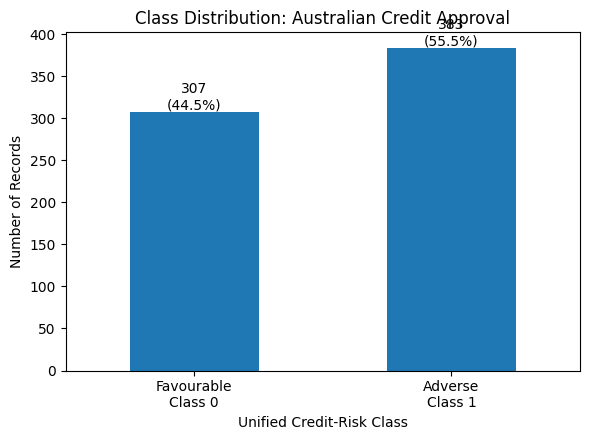

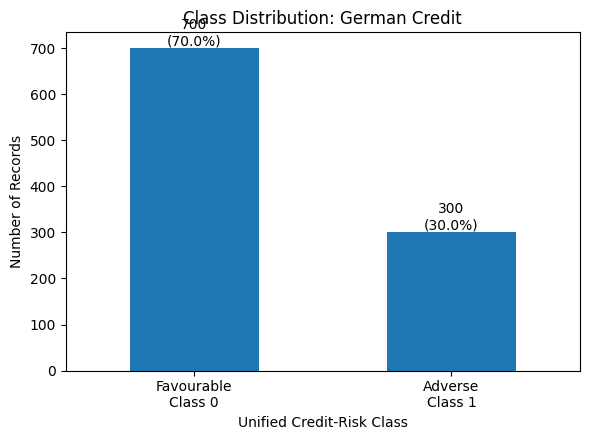

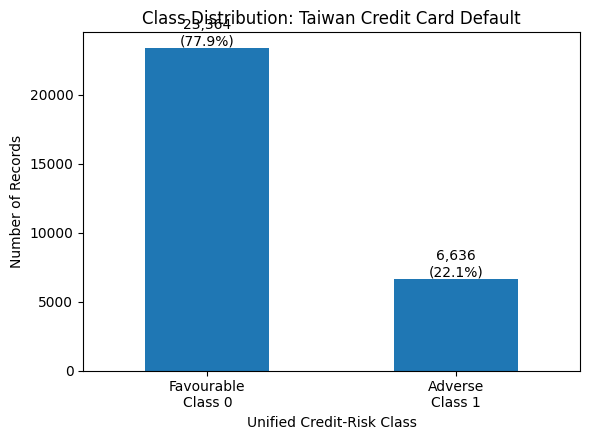

In [10]:
for dataset_name, dataset_information in datasets.items():
    dataframe = dataset_information["data"]

    class_counts = (
        dataframe["adverse_target"]
        .value_counts()
        .sort_index()
    )

    class_counts.index = [
        "Favourable\nClass 0",
        "Adverse\nClass 1"
    ]

    plt.figure(figsize=(6, 4.5))
    class_counts.plot(kind="bar")

    plt.title(
        f"Class Distribution: {dataset_name}",
        fontsize=12
    )
    plt.xlabel("Unified Credit-Risk Class")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=0)

    for index, value in enumerate(class_counts.values):
        plt.text(
            index,
            value,
            f"{value:,}\n({value / len(dataframe) * 100:.1f}%)",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    figure_name = (
        safe_slug(dataset_name)
        + "_class_distribution.png"
    )

    plt.savefig(
        FIGURES_DIR / figure_name,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [11]:
print("=" * 80)
print("FINAL DATASET AUDIT SUMMARY")
print("=" * 80)

print(dataset_overview.to_string(index=False))

print("\nFiles created in:")
print(AUDIT_DIR)

print("\nAudit files:")
for file_path in sorted(AUDIT_DIR.iterdir()):
    print(" -", file_path.name)

print("\nDataset audit completed successfully.")

FINAL DATASET AUDIT SUMMARY
                   dataset  records  predictors  categorical_features  ordinal_features  numerical_features  identifier_columns  favourable_cases  adverse_cases  adverse_rate  total_missing_values  exact_duplicate_rows  duplicate_predictor_profiles
Australian Credit Approval      690          14                     8                 0                   6                   0               307            383      0.555072                     0                     0                             0
             German Credit     1000          20                    13                 0                   7                   0               700            300      0.300000                     0                     0                             0
Taiwan Credit Card Default    30000          23                     3                 6                  14                   1             23364           6636      0.221200                     0                     0       